In [1]:
import numpy as np
from lbg_forecast.likelihood import Likelihood
import numpy as np
import matplotlib.pyplot as plt

import lbg_forecast.angular_power as ap
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

path = "./"
lhood_mismatch_int = Likelihood(path, override_seed=100, no_noise=True)

  
fid_params = np.array([lhood_mismatch_int._cosmo_fid.sigma8, 
                    lhood_mismatch_int._cosmo_fid.Omega_c, lhood_mismatch_int._cosmo_fid.Omega_b,
                    lhood_mismatch_int._cosmo_fid.h, lhood_mismatch_int._cosmo_fid.n_s,
                    lhood_mismatch_int._b_lbg_u, lhood_mismatch_int._b_lbg_g, lhood_mismatch_int._b_lbg_r])

Initialising likelihood
Initialisation Complete


In [ ]:

f, ax = plt.subplots(1, 1, figsize=(12, 7))

for i in range(4):

    loaded_results = np.load('biases/results_'+str(i)+'.npy')
    loaded_pdiffs = np.load('biases/pdiffs_'+str(i)+'.npy')
    loaded_grid = np.load('biases/grid_'+str(i)+'.npy')

    labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                            "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$"])
    lss = ['-', "--", "--","-.", "-.", ":", ":", ":"]
    init = loaded_results[-1, :]

    for param in range(fid_params.shape[0]):
        if(param == 0):
            ax.plot(loaded_grid, 100*(loaded_results[:, param] - loaded_results[-1, param])/loaded_results[-1, param], label=labels[param], ls=lss[param], lw=2)
    ax.legend(ncols=3, fontsize=18)
    fs=18

    ax.grid(alpha=0.5, ls='--')
    ax.set_xlim(-0.02, 1.02)
    #ax.set_ylim(-5.2, 5.2)
    ax.set_ylabel('Systematic Error (%)', fontsize=fs)
    ax.set_xlabel('Interloper Scaling Factor', fontsize=fs)
    ax.tick_params('x', labelsize=fs)
    ax.tick_params('y', labelsize=fs)

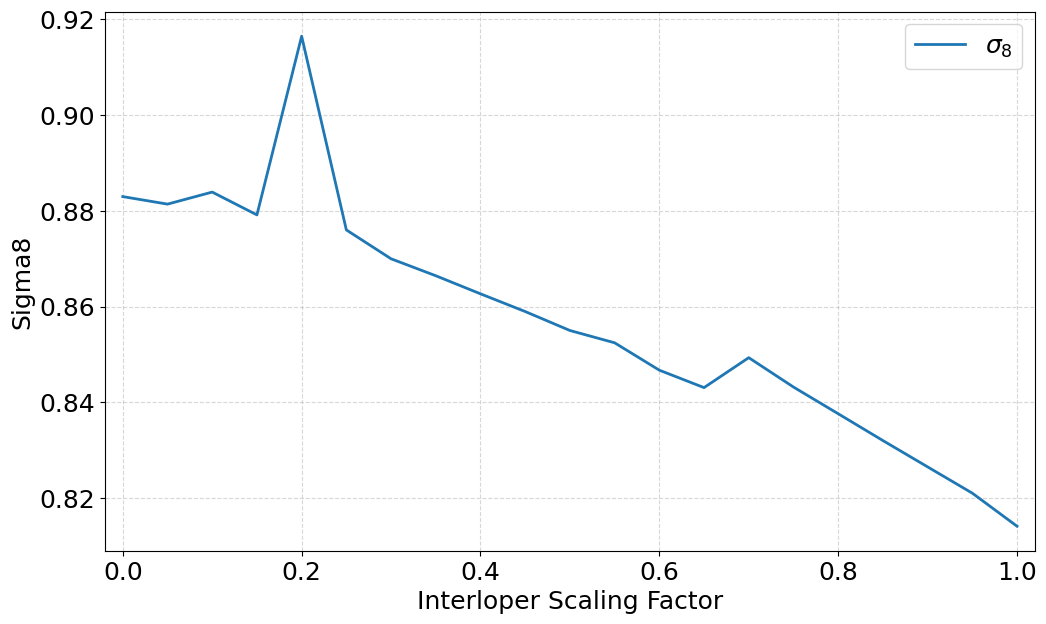

In [36]:
f, ax = plt.subplots(1, 1, figsize=(12, 7))    
i=0
loaded_results = np.load('biases/results_'+str(i)+'_intbinc'+'.npy')
loaded_pdiffs = np.load('biases/pdiffs_'+str(i)+'_intbinc'+'.npy')
loaded_grid = np.load('biases/grid_'+str(i)+'_intbinc'+'.npy')

labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$"])
lss = ['-', "--", "--","-.", "-.", ":", ":", ":"]
init = loaded_results[-1, :]

for param in range(fid_params.shape[0]):
    if(param == 0):
        ax.plot(loaded_grid, loaded_results[:, param], label=labels[param], ls=lss[param], lw=2)
ax.legend(ncols=3, fontsize=18)
fs=18

ax.grid(alpha=0.5, ls='--')
ax.set_xlim(-0.02, 1.02)
#ax.set_ylim(-5.2, 5.2)
ax.set_ylabel('Sigma8', fontsize=fs)
ax.set_xlabel('Interloper Scaling Factor', fontsize=fs)
ax.tick_params('x', labelsize=fs)
ax.tick_params('y', labelsize=fs)

(6.0, Array(1., dtype=float32))

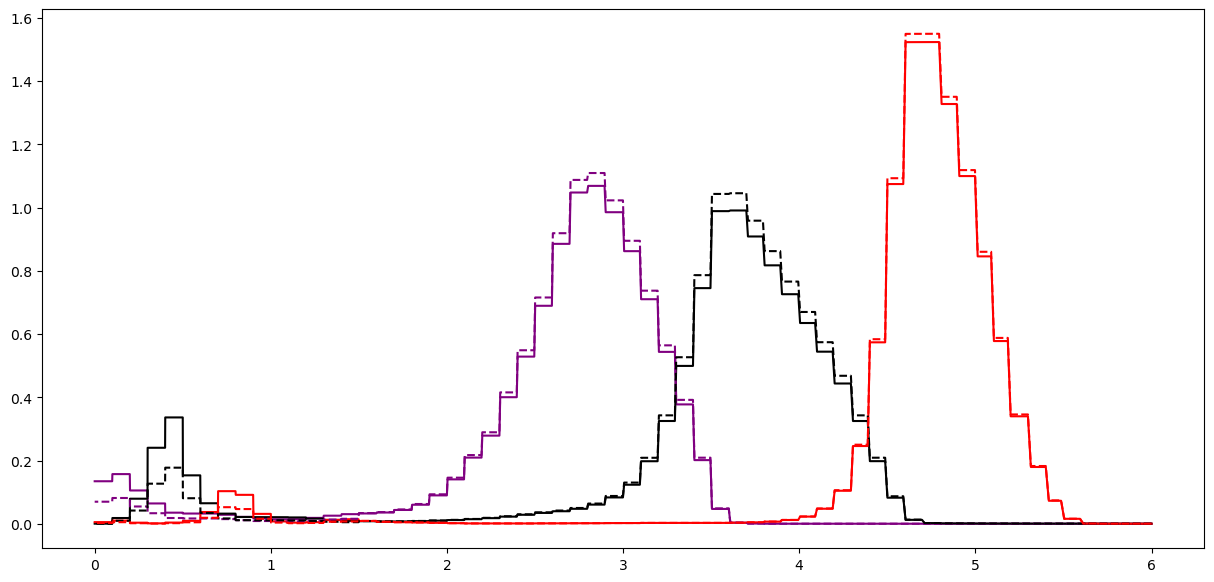

In [41]:
from lbg_forecast.modified_redshift import u_dropout
from lbg_forecast.modified_redshift import g_dropout
from lbg_forecast.modified_redshift import r_dropout
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from lbg_forecast.modified_redshift import u_dropout_nagaraj
from lbg_forecast.modified_redshift import g_dropout_nagaraj
from lbg_forecast.modified_redshift import r_dropout_nagaraj
from jax_cosmo.utils import a2z
from jax_cosmo.utils import z2a

#mean_vec_u_nag = jnp.load("4pca_data/npca_means_u_nag.npy")
#mean_vec_g_nag = jnp.load("4pca_data/npca_means_g_nag.npy")
#mean_vec_r_nag = jnp.load("4pca_data/npca_means_r_nag.npy")

#u_drop_nag = u_dropout_nagaraj(mean_vec_u_nag, red=1.0)
#g_drop_nag = g_dropout_nagaraj(mean_vec_g_nag, red=1.0)
#r_drop_nag = r_dropout_nagaraj(mean_vec_r_nag, red=1.0)


#plt.plot(u_drop_nag(np.linspace(0, 7, 100)), color='purple', ls='--')
#plt.plot(g_drop_nag(np.linspace(0, 7, 100)), color='black', ls='--')
#plt.plot(r_drop_nag(np.linspace(0, 7, 100)), color='red', ls='--')

mean_vec_u = jnp.load("4pca_data/npca_means_u.npy")
mean_vec_g = jnp.load("4pca_data/npca_means_g.npy")
mean_vec_r = jnp.load("4pca_data/npca_means_r.npy")

u_drop = u_dropout(mean_vec_u, red=1.0)
g_drop = g_dropout(mean_vec_g, red=1.0)
r_drop = r_dropout(mean_vec_r, red=1.0)

u_drop2 = u_dropout(mean_vec_u, red=0.5)
g_drop2 = g_dropout(mean_vec_g, red=0.5)
r_drop2 = r_dropout(mean_vec_r, red=0.5)

f, ax = plt.subplots(1, 1, figsize=(15, 7))
z = a2z(np.linspace(z2a(6.0), 1, 2048))
plt.plot(z, u_drop(z), color='purple')
plt.plot(z, g_drop(z), color='black')
plt.plot(z, r_drop(z), color='red')

plt.plot(z, u_drop2(z), color='purple', ls='--')
plt.plot(z, g_drop2(z), color='black', ls='--')
plt.plot(z, r_drop2(z), color='red', ls='--')

from jax_cosmo.scipy.integrate import simps
norm = simps(lambda t: u_drop(t), 0.0, 6.0, 1024)
u_drop2.zmax, norm


(5000, 100, 8)


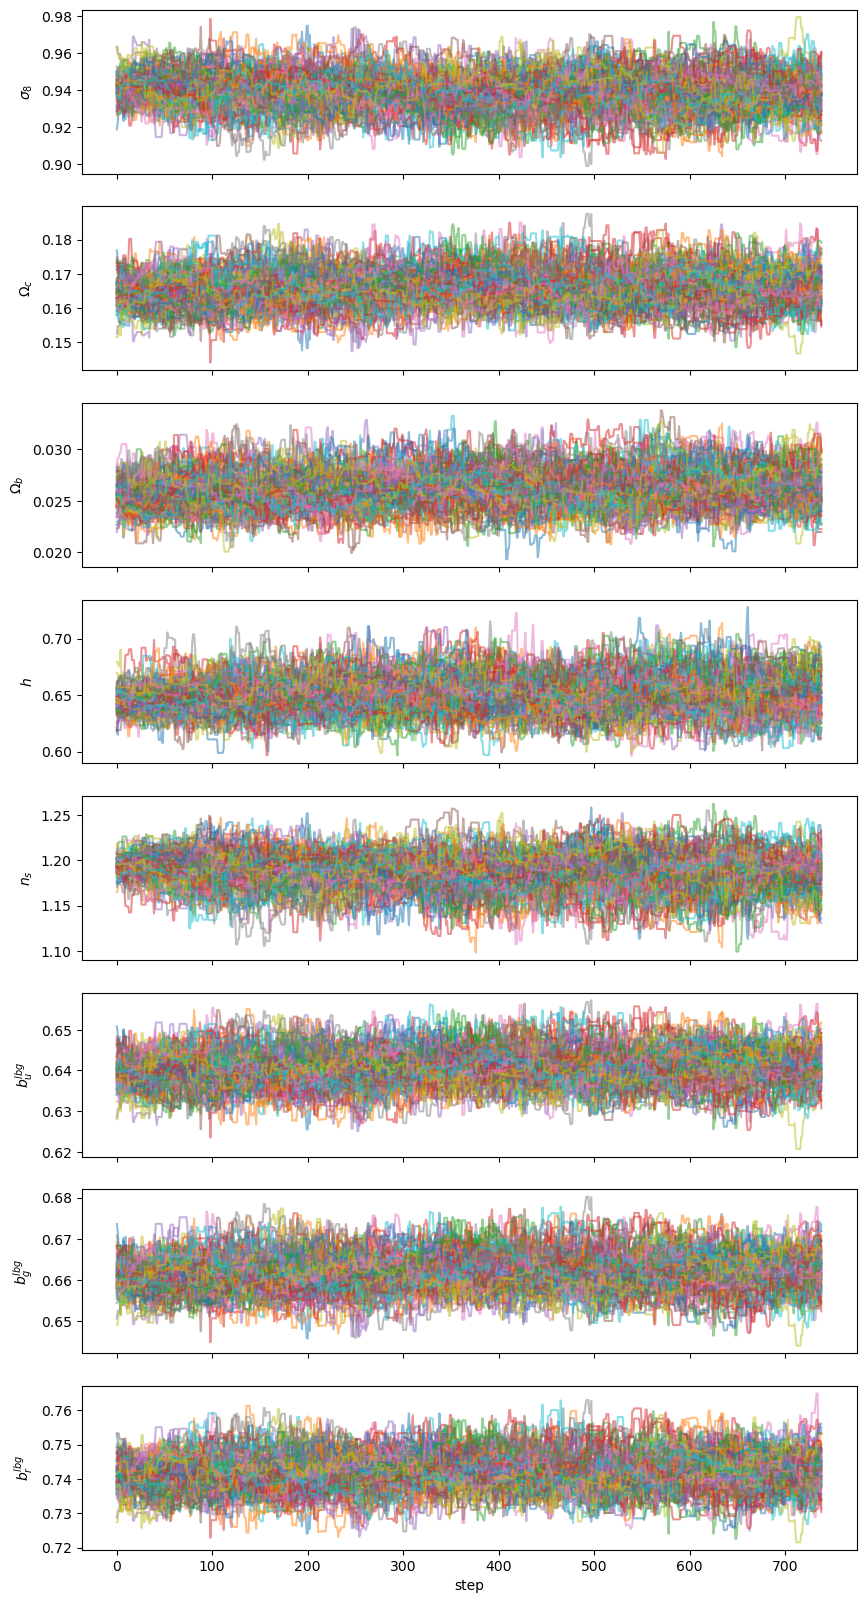

0.9388463015700791

In [67]:
import h5py

with h5py.File("emcee_run_closer_start.h5", "r") as f:
    chain = f["mcmc"]["chain"][:]  # shape: (nwalkers, nsteps, ndim)
    print(chain.shape)


labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$"])

start=100
end=839
samples_chain = chain[start:end, :, :]
ndim = fid_params.shape[0]
nwalkers = chain.shape[1]

fig, axes = plt.subplots(ndim, figsize=(10, 20), sharex=True)
for i in range(ndim):
    for w in range(nwalkers):
        axes[i].plot(samples_chain[:, w, i], alpha=0.5)
    axes[i].set_ylabel(labels[i])
    #mean = np.mean((samples_chain[:, :, i]).flatten(), axis=0)
    #std = np.std((samples_chain[:, :, i]).flatten(), axis=0)
    #print(mean, std)
axes[-1].set_xlabel("step")
plt.show()

mean = np.mean((samples_chain[:, :, 0]).flatten(), axis=0)
std = np.std((samples_chain[:, :, 0]).flatten(), axis=0)
#print(mean - 5*std, mean, std)

np.mean((samples_chain[start:end, :, 0]).flatten(), axis=0)